## PHASE 1 — Data Import and Data Exploration

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loading datasets
cust = pd.read_csv('dim_customer.csv')
policies = pd.read_csv('dim_policies.csv')
premiums = pd.read_csv('fact_premiums.csv')
settlements = pd.read_csv('fact_settlements.csv')
dates = pd.read_csv('dim_date.csv')

# Checking dataset dimensions
print("DATASET SHAPES")
print("Customer Table:", cust.shape)
print("Policies Table:", policies.shape)
print("Premiums Table:", premiums.shape)
print("Settlements Table:", settlements.shape)
print("Date Table:", dates.shape)

# Previewing datasets
print("\nCUSTOMER TABLE PREVIEW")
print(cust.head())

print("\nPREMIUM TABLE PREVIEW")
print(premiums.head())

# Checking data types
print("\nDATA TYPES")
print(cust.dtypes)


DATASET SHAPES
Customer Table: (26841, 5)
Policies Table: (9, 3)
Premiums Table: (26841, 7)
Settlements Table: (73, 3)
Date Table: (181, 4)

CUSTOMER TABLE PREVIEW
  customer_code         dob       city  Age AgeGroup
0        SUNX9H  10/24/2005  Delhi NCR   18    18-24
1        SUN36T  10/24/2005  Delhi NCR   18    18-24
2        SUNJ4Q  10/21/2005  Delhi NCR   18    18-24
3        SUN2TY  10/19/2005  Delhi NCR   18    18-24
4       SUN2632  10/19/2005  Delhi NCR   18    18-24

PREMIUM TABLE PREVIEW
         date customer_code   policy_id     sales_mode  \
0  12/01/2022       SUNSSVU  POL4321HEL  Offline-Agent   
1  12/02/2022        SUN2QA  POL4321HEL  Offline-Agent   
2  12/02/2022         SUNPF  POL4321HEL  Offline-Agent   
3  12/03/2022        SUNXB9  POL4321HEL  Offline-Agent   
4  12/03/2022       SUNIW8D  POL4321HEL  Offline-Agent   

   final_premium_amt(INR) Mode: Online/Offline Mode:Through Mediun  
0                    5100              Offline               Agent  
1       

## PHASE 2 — Data Cleaning


In [14]:
# Checking missing values
print("\nMISSING VALUES")
print(cust.isnull().sum())

print("\nDUPLICATE RECORDS")
print("Customer Duplicates :", cust.duplicated().sum())
print("Premium Duplicates  :", premiums.duplicated().sum())

# Removing duplicates if available
cust.drop_duplicates(inplace=True)
premiums.drop_duplicates(inplace=True)

# Checking null values again
print("\nCLEANED DATA SHAPES")
print("Customer Table :", cust.shape)
print("Premium Table  :", premiums.shape)



MISSING VALUES
customer_code    0
dob              0
city             0
Age              0
AgeGroup         0
dtype: int64

DUPLICATE RECORDS
Customer Duplicates : 0
Premium Duplicates  : 0

CLEANED DATA SHAPES
Customer Table : (26841, 5)
Premium Table  : (26841, 7)


## PHASE 3 — Data Transformation


In [15]:
# Revenue by city
city_revenue = premiums.merge(cust,on='customer_code',how='left')

city_revenue_analysis = city_revenue.groupby('city')['final_premium_amt(INR)'].sum().reset_index()

# Revenue by sales mode
sales_mode_analysis = premiums.groupby('Mode: Online/Offline')['final_premium_amt(INR)'].sum().reset_index()

# Monthly revenue trend
monthly_data = premiums.merge(dates,on='date',how='left')

monthly_revenue = monthly_data.groupby('mmm_yy')['final_premium_amt(INR)'].sum().reset_index()

print("\nCITY-WISE REVENUE")
print(city_revenue_analysis.head())

print("\nSALES MODE REVENUE")
print(sales_mode_analysis)

print("\nMONTHLY REVENUE")
print(monthly_revenue.head())


CITY-WISE REVENUE
        city  final_premium_amt(INR)
0    Chennai               106306560
1  Delhi NCR               401569473
2  Hyderabad               160522521
3     Indore                81345320
4     Mumbai               239508975

SALES MODE REVENUE
  Mode: Online/Offline  final_premium_amt(INR)
0              Offline               703661369
1               Online               285591480

MONTHLY REVENUE
   mmm_yy  final_premium_amt(INR)
0  Apr_23               153749748
1  Dec_22               156318863
2  Feb_23               142639681
3  Jan_23               141019417
4  Mar_23               263838382


## PHASE 4 —Insights Generation


 EXECUTIVE KPI SUMMARY
Total Revenue       : ₹ 989,252,849.00
Average Premium     : ₹ 36,856.04
Total Customers     : 26841


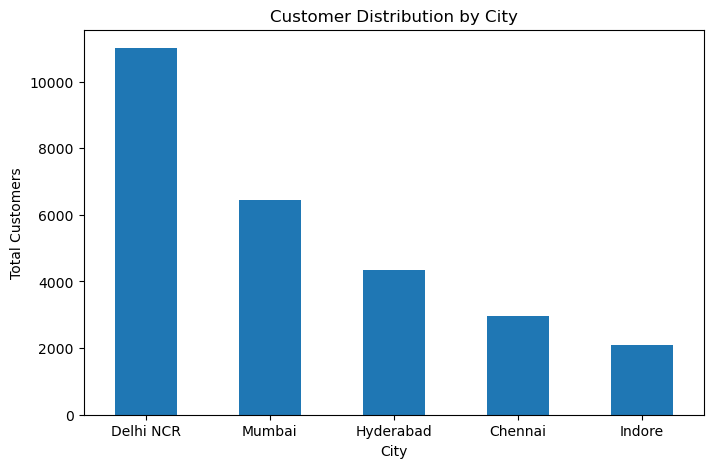

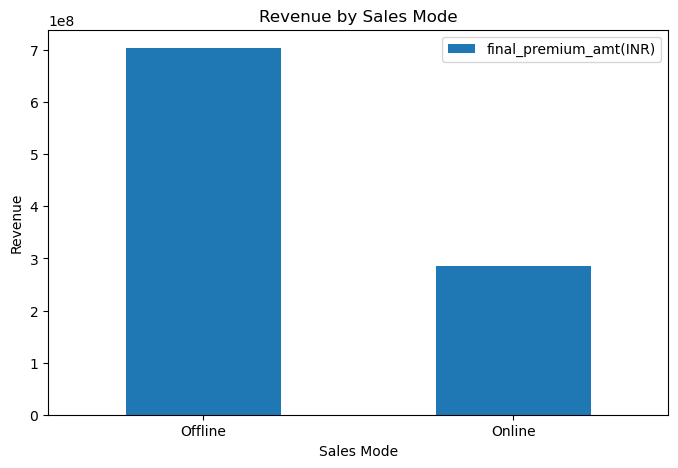

In [18]:
# Total Revenue
total_revenue = premiums['final_premium_amt(INR)'].sum()

# Average Premium
average_premium = premiums['final_premium_amt(INR)'].mean()

# Total Customers
total_customers = cust['customer_code'].nunique()

print("\n EXECUTIVE KPI SUMMARY")
print(f"Total Revenue       : ₹ {total_revenue:,.2f}")
print(f"Average Premium     : ₹ {average_premium:,.2f}")
print(f"Total Customers     : {total_customers}")

# Visualizations

# Customer Distribution by City
cust['city'].value_counts().plot(kind='bar',figsize=(8,5))

plt.title("Customer Distribution by City")
plt.xlabel("City")
plt.ylabel("Total Customers")
plt.xticks(rotation=0)
plt.show()


# Revenue by Sales Mode
sales_mode_analysis.plot(
    x='Mode: Online/Offline',
    y='final_premium_amt(INR)',
    kind='bar',
    figsize=(8,5)
)

plt.title("Revenue by Sales Mode")
plt.xlabel("Sales Mode")
plt.ylabel("Revenue")
plt.xticks(rotation=0)

plt.show()
